# Project 9 — Limit Order Book: Reconstruction, Queueing Simulation, Price Impact, Resiliency and Latency Arbitrage

**Goal.** Build a limit order book (LOB) from raw exchange messages, calibrate a **queueing (zero-intelligence) model** of the book to it,
simulate the book, and use both the real and the simulated book to study **price impact**, **market resiliency** and **latency arbitrage**.

**Data.** Databento **MBO** (market-by-order, CME Globex MDP 3.0) for the E-mini S&P 500 (**ESM5**) and Micro E-mini (**MESM5**) on
Wednesday 2025-05-14: every add, cancel, modify and trade message with nanosecond timestamps, ≈ 10 million messages per contract.
Analysis uses US regular trading hours (13:30–20:00 UTC).

| § | Content |
|---|---|
| 1 | LOB mechanics and the models (queueing / zero-intelligence / agent-based) |
| 2 | Reconstructing the book from MBO messages |
| 3 | Stylised facts of the real ES book |
| 4 | Calibrating the Cont–Stoikov–Talreja queueing model |
| 5 | Simulating the book and comparing it with reality |
| 6 | Price impact: order-flow imbalance, trade response, metaorders and the square-root law |
| 7 | Resiliency: how fast does the book refill after a shock? |
| 8 | Latency arbitrage between ES and MES |
| 9 | Strengths, weaknesses, extensions |

## 1. The LOB and how to model it
A LOB is a set of queues of resting limit orders at each price. Three event types change it:
* **limit orders** join a queue (price-time priority: at the back);
* **cancellations** leave a queue;
* **market orders** (marketable orders) consume the queue at the best opposite price.

Model families:
| Family | Idea | Examples |
|---|---|---|
| Zero-intelligence / queueing | order flow is a set of independent Poisson processes whose rates depend only on the distance to the best price | Smith–Farmer (2003), **Cont–Stoikov–Talreja (2010)**, Huang–Lehalle–Rosenbaum queue-reactive (2015) |
| Agent-based | heterogeneous strategic agents (market makers, noise, informed, HFT) interact | Santa-Fe, Chiarella–Iori, ABIDES |
| Propagator / impact | prices respond to signed order flow with a decaying kernel | Bouchaud et al. (2004), Obizhaeva–Wang (2013) |

**Cont–Stoikov–Talreja (CST).** At distance $i$ ticks from the *opposite* best quote, limit orders arrive at rate $\lambda(i)$, each resting order is
cancelled at rate $\theta(i)$, and market orders arrive at rate $\mu$. The book is then a continuous-time Markov chain, simple enough to calibrate
from counts and to simulate exactly (Gillespie algorithm), yet it reproduces much of the LOB's shape. Its known limits (no memory, no strategic
behaviour) are part of what we'll see.

In [1]:
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numba as nb
import statsmodels.api as sm
from IPython.display import display

from qdata import mbo_events
from lob_tools import rebuild_book

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
TICK_FIXED = 250_000_000            # 0.25 index points in Databento fixed-point (1e-9) units
RTH = (pd.Timestamp("2025-05-14 13:30", tz="UTC"), pd.Timestamp("2025-05-14 20:00", tz="UTC"))

ev = mbo_events("2025-05-14", ("ESM5", "MESM5"))
ev = ev.sort_values(["ts_recv", "sequence"]).reset_index(drop=True)
print(f"{len(ev):,} MBO messages")
ev.groupby("symbol").action.value_counts().unstack()

20,471,097 MBO messages


action,A,C,F,M,R,T
symbol,,,,,,
ESM5,4118232,4110898,851266,891625,1,405711
MESM5,4033163,4024742,627537,1029633,1,378288


## 2. Reconstructing the book
`lob_tools.rebuild_book` replays the messages through a numba-compiled order book. It keeps a map from order id to (side, price, size), plus
aggregate size per price. Two details matter:
* **The session starts with a snapshot** (a clear `R`, followed by an add for every resting order), so we must replay from the start of the file,
  not from 13:30.
* **The book is only consistent at the end of an event packet.** One aggressive order generates several messages (trade, fills, cancels), and in
  between the book can look crossed. We record a snapshot only on messages flagged `F_LAST`.

Sanity checks: the reconstructed book must never be crossed, and trades must print at the best quotes.

In [2]:
t0 = time.time()
books = {}
for sym in ["ESM5", "MESM5"]:
    b = rebuild_book(ev[ev.symbol == sym], TICK_FIXED, depth=5)
    b["ts"] = pd.to_datetime(b.ts, utc=True)
    books[sym] = b
print(f"rebuilt 2 books in {time.time()-t0:.1f}s")
es = books["ESM5"]
es_rth = es[(es.ts >= RTH[0]) & (es.ts < RTH[1])].reset_index(drop=True)
print(f"ES snapshots in RTH: {len(es_rth):,};  crossed/locked states: {(es_rth.ask <= es_rth.bid).sum()}")

tr = ev[(ev.symbol == "ESM5") & (ev.action == "T") & (ev.ts_recv >= RTH[0]) & (ev.ts_recv < RTH[1])].copy()
tr["px"] = tr.price // TICK_FIXED
q = pd.merge_asof(tr[["ts_recv", "px", "side", "size"]].rename(columns={"ts_recv": "ts"}), es[["ts", "bid", "ask"]],
                  on="ts", direction="backward", allow_exact_matches=False)
at_best = ((q.side == "B") & (q.px >= q.ask)) | ((q.side == "A") & (q.px <= q.bid))
print(f"trades printing at (or through) the prevailing best quote on the aggressor's side: {at_best.mean():.1%}")

rebuilt 2 books in 7.4s
ES snapshots in RTH: 7,012,676;  crossed/locked states: 0


trades printing at (or through) the prevailing best quote on the aggressor's side: 99.5%


## 3. Stylised facts of the ES book

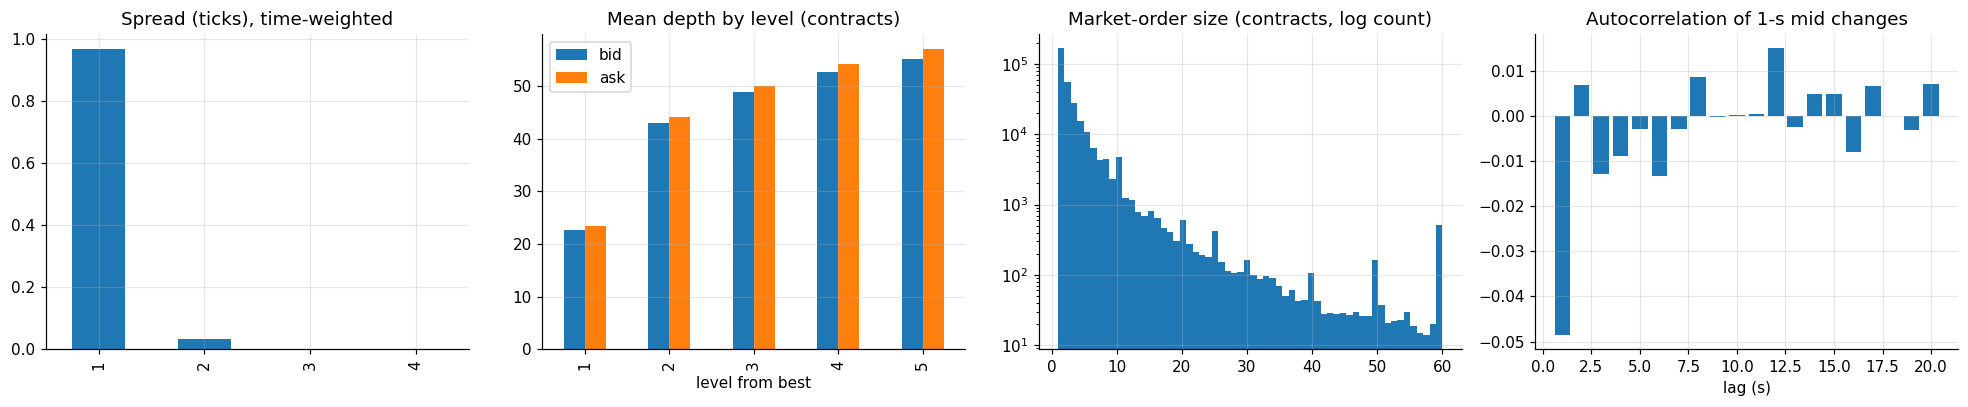

RTH: 311,069 market orders, median size 1, 0.73% walk more than one level; mid changes: 248,364


In [3]:
es_rth["mid"] = (es_rth.bid + es_rth.ask) / 2
es_rth["spread"] = es_rth.ask - es_rth.bid
dt_snap = es_rth.ts.diff().dt.total_seconds().shift(-1).fillna(0).clip(upper=5)      # time-weighting
spread_dist = dt_snap.groupby(es_rth.spread).sum() / dt_snap.sum()
depth_prof = pd.DataFrame({"bid": [np.average(es_rth[f"bsz{j}"], weights=dt_snap) for j in range(1, 6)],
                           "ask": [np.average(es_rth[f"asz{j}"], weights=dt_snap) for j in range(1, 6)]}, index=range(1, 6))

# aggressive orders: group trade messages of the same packet (same ts_event & aggressor side) into one market order
mo = tr.groupby(["ts_event", "side"]).agg(size=("size", "sum"), px_first=("px", "first"), px_last=("px", "last"),
                                          ts=("ts_recv", "first")).reset_index()
mo["levels_walked"] = (mo.px_last - mo.px_first).abs()

fig, axs = plt.subplots(1, 4, figsize=(18, 3.8))
spread_dist.head(4).plot.bar(ax=axs[0]); axs[0].set_title("Spread (ticks), time-weighted"); axs[0].set_xlabel("")
depth_prof.plot.bar(ax=axs[1]); axs[1].set_title("Mean depth by level (contracts)"); axs[1].set_xlabel("level from best")
axs[2].hist(mo["size"].clip(upper=60), bins=60, log=True); axs[2].set_title("Market-order size (contracts, log count)")
m1s = es_rth.set_index("ts").mid.resample("1s").last().ffill()
ac = [np.corrcoef(np.diff(m1s.values)[:-l], np.diff(m1s.values)[l:])[0, 1] for l in range(1, 21)]
axs[3].bar(range(1, 21), ac); axs[3].set_title("Autocorrelation of 1-s mid changes"); axs[3].set_xlabel("lag (s)")
plt.tight_layout(); plt.show()
print(f"RTH: {len(mo):,} market orders, median size {mo['size'].median():.0f}, "
      f"{(mo.levels_walked > 0).mean():.2%} walk more than one level; mid changes: {(es_rth.mid.diff() != 0).sum():,}")

* ES is a **large-tick** market: the spread is one tick (0.25 pt = \$12.50) almost all the time, and the price moves only when a queue at
  the best is exhausted (or refilled inside a two-tick spread).
* **Depth increases away from the best**: level 1 is thinner than levels 2–5, because the best queue is constantly eaten by market orders,
  while deeper queues only face cancellations.
* Market orders are small (median one or two contracts, with a heavy tail) and almost never walk the book. Large traders split orders.
* Short-horizon mid changes are slightly **negatively autocorrelated** (bid–ask bounce and queue refills).

## 4. Calibrating the CST model
For every add and cancel during RTH we compute its distance $i$ (in ticks) from the **opposite** best quote at that moment. A buy limit order at the
best bid with a one-tick spread has $i=1$. Then:
$$\hat\lambda(i)=\frac{N_{\text{adds}}(i)}{T},\qquad \hat\theta(i)=\frac{N_{\text{cancels}}(i)}{T\cdot\bar Q_i},\qquad \hat\mu=\frac{N_{\text{MO}}}{T}\cdot\frac{\bar S_{MO}}{\bar S_{L}},$$
with sizes in units of the average limit-order size $\bar S_L$ (CST §4). $\bar Q_i$ is the mean queue size (in those units) at distance $i$. Both sides are
pooled (the model is symmetric).

In [4]:
K = 5
er = ev[(ev.symbol == "ESM5") & (ev.ts_recv >= RTH[0]) & (ev.ts_recv < RTH[1]) & ev.action.isin(["A", "C"])].copy()
er["px"] = er.price // TICK_FIXED
er = pd.merge_asof(er.rename(columns={"ts_recv": "ts"}), es[["ts", "bid", "ask"]], on="ts", direction="backward",
                   allow_exact_matches=False)
er["dist"] = np.where(er.side == "B", er.ask - er.px, er.px - er.bid)
T_sec = (RTH[1] - RTH[0]).total_seconds()
S_L = er.loc[er.action == "A", "size"].mean()
adds = er[(er.action == "A") & er.dist.between(1, K)].groupby("dist").size() / T_sec / 2          # per side
cans = er[(er.action == "C") & er.dist.between(1, K)].groupby("dist").size() / T_sec / 2
# mean queue size at distance i from the opposite best (level j from own best = i - spread + 1; with 1-tick spread level j = i)
Qbar = depth_prof.mean(1).values / S_L
lam = adds.reindex(range(1, K + 1)).values
theta = cans.reindex(range(1, K + 1)).values / Qbar
mu = len(mo) / T_sec / 2 * (mo["size"].mean() / S_L)
calib = pd.DataFrame({"λ(i) adds/s": lam, "θ(i) cancel rate per order-unit/s": theta, "mean queue (units)": Qbar}, index=pd.Index(range(1, K + 1), name="i"))
print(f"avg limit-order size S_L = {S_L:.2f} contracts; market-order rate μ = {mu:.3f} units/s per side")
calib

avg limit-order size S_L = 1.61 contracts; market-order rate μ = 12.295 units/s per side


,λ(i) adds/s,θ(i) cancel rate per order-unit/s,mean queue (units)
i,,,
1,48.8243,3.6705,14.3533
2,7.3107,0.2274,27.0931
3,2.7144,0.0599,30.8210
4,1.5894,0.0381,33.2700
5,1.3716,0.0342,34.9206


## 5. Simulating the book
The simulator keeps queue sizes (in units) on a price grid around the mid, and uses the **Gillespie algorithm**: draw the time to the next event
from the total rate, pick the event in proportion to its rate, update the book. We add two standard ingredients to the plain CST chain:
* **market orders** consume one unit from the best opposite queue; when a queue empties, the best price moves;
* **beyond level K** the book is re-seeded with the mean depth when the window shifts (CST's boundary condition).

Everything is compiled with numba: 6.5 simulated hours take a few seconds.

In [5]:
@nb.njit(cache=True)
def simulate_cst(lam, theta, mu, q0, n_steps, seed, meta_rate=0.0, meta_units=0.0, meta_start=0.0, meta_end=0.0,
                 shock_t=-1.0, shock_levels=0):
    """Returns event times, best bid/ask (ticks), depth at best bid/ask. Optional metaorder (extra buy market orders at
    `meta_rate` per second between meta_start and meta_end, total `meta_units`) and an ask-side depletion shock at shock_t."""
    np.random.seed(seed)
    Kk = len(lam)
    NP = 4000
    bid_q = np.zeros(NP); ask_q = np.zeros(NP)
    mid0 = NP // 2
    bb, ba = mid0 - 1, mid0                          # best bid / ask indices (1-tick spread)
    for j in range(Kk):
        bid_q[bb - j] = q0[j]; ask_q[ba + j] = q0[j]
    t = 0.0
    out_t = np.empty(n_steps); out_b = np.empty(n_steps, np.int64); out_a = np.empty(n_steps, np.int64)
    out_bq = np.empty(n_steps); out_aq = np.empty(n_steps)
    meta_done = 0.0
    shocked = False
    for s in range(n_steps):
        # rates: limit orders at distance 1..K from the opposite best, cancels proportional to queue, market orders
        r_lb = lam.copy(); r_la = lam.copy()
        r_cb = np.empty(Kk); r_ca = np.empty(Kk)
        for i in range(Kk):
            pb = ba - 1 - i; pa = bb + 1 + i          # price at distance i+1 from the opposite best
            r_cb[i] = theta[i] * bid_q[pb] if pb >= 0 else 0.0
            r_ca[i] = theta[i] * ask_q[pa] if pa < NP else 0.0
        in_meta = meta_start <= t < meta_end and meta_done < meta_units
        r_mb = mu + (meta_rate if in_meta else 0.0)   # buy market orders hit the ask
        r_ms = mu
        R = r_lb.sum() + r_la.sum() + r_cb.sum() + r_ca.sum() + r_mb + r_ms
        t += np.random.exponential(1.0 / R)
        if shock_t >= 0 and not shocked and t >= shock_t:
            for j in range(shock_levels):            # wipe out the first `shock_levels` ask levels
                ask_q[ba + j] = 0.0
            ba += shock_levels
            shocked = True
        u = np.random.random() * R
        acc = 0.0
        done = False
        for i in range(Kk):
            acc += r_lb[i]
            if u < acc:
                bid_q[ba - 1 - i] += 1.0
                if ba - 1 - i > bb: bb = ba - 1 - i
                done = True; break
        if not done:
            for i in range(Kk):
                acc += r_la[i]
                if u < acc:
                    ask_q[bb + 1 + i] += 1.0
                    if bb + 1 + i < ba: ba = bb + 1 + i
                    done = True; break
        if not done:
            for i in range(Kk):
                acc += r_cb[i]
                if u < acc:
                    bid_q[ba - 1 - i] = max(bid_q[ba - 1 - i] - 1.0, 0.0); done = True; break
        if not done:
            for i in range(Kk):
                acc += r_ca[i]
                if u < acc:
                    ask_q[bb + 1 + i] = max(ask_q[bb + 1 + i] - 1.0, 0.0); done = True; break
        if not done:
            acc += r_mb
            if u < acc:
                ask_q[ba] = max(ask_q[ba] - 1.0, 0.0)
                if in_meta and u >= acc - (meta_rate if in_meta else 0.0):
                    meta_done += 1.0
            else:
                bid_q[bb] = max(bid_q[bb] - 1.0, 0.0)
        # repair best prices; re-seed deep levels with the mean depth if the book thins out
        while bid_q[bb] <= 0.0 and bb > 0:
            bb -= 1
            if ba - bb > Kk + 2:
                bb = ba - 1 - Kk
                for j in range(Kk): bid_q[bb - j] = max(bid_q[bb - j], q0[j])
                bb = ba - 1 if bid_q[ba - 1] > 0 else bb
                while bid_q[bb] <= 0: bb -= 1
                break
        while ask_q[ba] <= 0.0 and ba < NP - 1:
            ba += 1
            if ba - bb > Kk + 2:
                ba = bb + 1 + Kk
                for j in range(Kk): ask_q[ba + j] = max(ask_q[ba + j], q0[j])
                ba = bb + 1 if ask_q[bb + 1] > 0 else ba
                while ask_q[ba] <= 0: ba += 1
                break
        # keep the window centred
        if bb < 200 or ba > NP - 200:
            shift = (bb + ba) // 2 - mid0
            bid_q = np.roll(bid_q, -shift); ask_q = np.roll(ask_q, -shift)
            bb -= shift; ba -= shift
        out_t[s] = t; out_b[s] = bb; out_a[s] = ba; out_bq[s] = bid_q[bb]; out_aq[s] = ask_q[ba]
    return out_t, out_b, out_a, out_bq, out_aq


t0 = time.time()
n_est = int(T_sec * (2 * lam.sum() + 2 * (theta * Qbar).sum() + 2 * mu))
st, sb, sa, sbq, saq = simulate_cst(lam, theta, mu, Qbar, n_est, 1)
print(f"simulated {n_est:,} events ({st[-1]/3600:.2f} h) in {time.time()-t0:.1f}s")
sim = pd.DataFrame({"t": st, "bid": sb, "ask": sa, "bq": sbq * S_L, "aq": saq * S_L})
sim["mid"] = (sim.bid + sim.ask) / 2; sim["spread"] = sim.ask - sim.bid

simulated 6,423,557 events (7.22 h) in 0.6s


,real ES,CST simulation
P(spread = 1 tick),0.9664,0.9991
mean depth at best (contracts),23.0436,16.1872
mid changes per minute,636.8308,11.6139
σ of 1-min mid change (ticks),7.5564,1.4512
σ of 5-min mid change (ticks),15.6947,3.1656


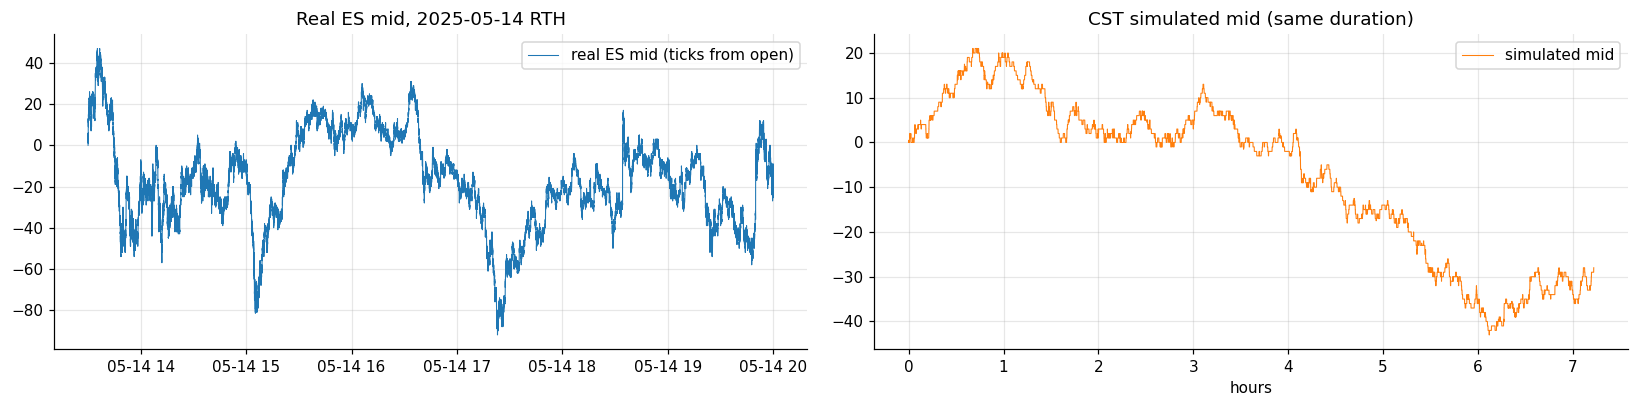

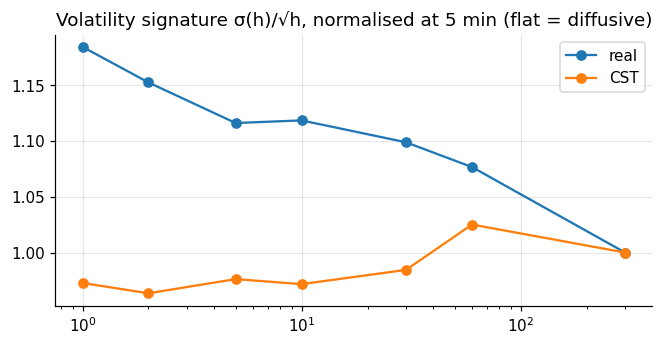

In [6]:
def vol_signature(t_sec, mid, horizons):
    s = pd.Series(mid, index=pd.to_datetime(t_sec, unit="s"))
    return [np.std(np.diff(s.resample(f"{h}s").last().ffill().values)) / np.sqrt(h) for h in horizons]


real_t = (es_rth.ts - es_rth.ts.iloc[0]).dt.total_seconds().values
hz = [1, 2, 5, 10, 30, 60, 300]
wsim = np.diff(np.r_[sim.t.values, sim.t.values[-1]])
cmp = pd.DataFrame({
    "real ES": {"P(spread = 1 tick)": spread_dist.get(1, 0), "mean depth at best (contracts)": depth_prof.iloc[0].mean(),
                "mid changes per minute": (es_rth.mid.diff() != 0).sum() / (T_sec / 60),
                "σ of 1-min mid change (ticks)": vol_signature(real_t, es_rth.mid.values, [60])[0] * np.sqrt(60),
                "σ of 5-min mid change (ticks)": vol_signature(real_t, es_rth.mid.values, [300])[0] * np.sqrt(300)},
    "CST simulation": {"P(spread = 1 tick)": np.sum(wsim * (sim.spread.values == 1)) / wsim.sum(),
                       "mean depth at best (contracts)": np.average((sim.bq + sim.aq) / 2, weights=wsim),
                       "mid changes per minute": (sim.mid.diff() != 0).sum() / (sim.t.iloc[-1] / 60),
                       "σ of 1-min mid change (ticks)": vol_signature(sim.t.values, sim.mid.values, [60])[0] * np.sqrt(60),
                       "σ of 5-min mid change (ticks)": vol_signature(sim.t.values, sim.mid.values, [300])[0] * np.sqrt(300)}})
display(cmp)

fig, axs = plt.subplots(1, 2, figsize=(15, 3.8))
axs[0].plot(es_rth.ts.iloc[::50], (es_rth.mid.iloc[::50] - es_rth.mid.iloc[0]), lw=.7, label="real ES mid (ticks from open)")
axs[0].set_title("Real ES mid, 2025-05-14 RTH"); axs[0].legend()
axs[1].plot(sim.t.iloc[::50] / 3600, sim.mid.iloc[::50] - sim.mid.iloc[0], lw=.7, color="tab:orange", label="simulated mid")
axs[1].set_title("CST simulated mid (same duration)"); axs[1].set_xlabel("hours"); axs[1].legend()
plt.tight_layout(); plt.show()
vs = pd.DataFrame({"real": vol_signature(real_t, es_rth.mid.values, hz), "CST": vol_signature(sim.t.values, sim.mid.values, hz)}, index=hz)
(vs / vs.iloc[-1]).plot(logx=True, marker="o", title="Volatility signature σ(h)/√h, normalised at 5 min (flat = diffusive)", figsize=(7, 3.2)); plt.show()

**How realistic is the zero-intelligence book?** It reproduces the *static* large-tick structure (a one-tick spread, queues of the right order of
magnitude) from nothing but event counts. But it gets **price dynamics badly wrong**: the simulated mid changes ~50× less often than the real one, and its
1-minute volatility is ~5× too low. The reason is visible in the calibration table. With constant rates, the best queue is a birth–death process whose inflow
(λ(1) ≈ 49/s) balances cancellations plus market orders at ≈ 10 units, and a queue that mean-reverts to 10 almost never hits zero. Real queues empty
all the time because the rates are **not constant**:
* cancellations accelerate when a queue gets short (nobody wants to be last in a vanishing queue), which is the *queue-reactive* effect of Huang, Lehalle &
  Rosenbaum (2015);
* order flow clusters in time (self-exciting, Hawkes-like), and order signs are persistent because metaorders are split.

Calibrating "average" rates and plugging them into a memoryless model loses exactly the state dependence that moves prices.

## 6. Price impact
### 6.1 Order-flow imbalance (real data)
Cont, Kukanov & Stoikov (2014): over an interval, the **order-flow imbalance** $\text{OFI}=\sum_n e_n$, with
$e_n = \mathbb 1_{b_n\ge b_{n-1}}q^b_n-\mathbb 1_{b_n\le b_{n-1}}q^b_{n-1}-\mathbb 1_{a_n\le a_{n-1}}q^a_n+\mathbb 1_{a_n\ge a_{n-1}}q^a_{n-1}$, explains
mid-price changes linearly, $\Delta P=\beta\,\text{OFI}+\varepsilon$, with $\beta\propto1/\text{depth}$.

,β (ticks per contract),t-stat,R²,1/mean depth
interval,,,,
1s,0.0100,204.5035,0.6413,0.0429
10s,0.0106,84.6954,0.7543,0.0426
60s,0.0108,33.9715,0.7489,0.0425


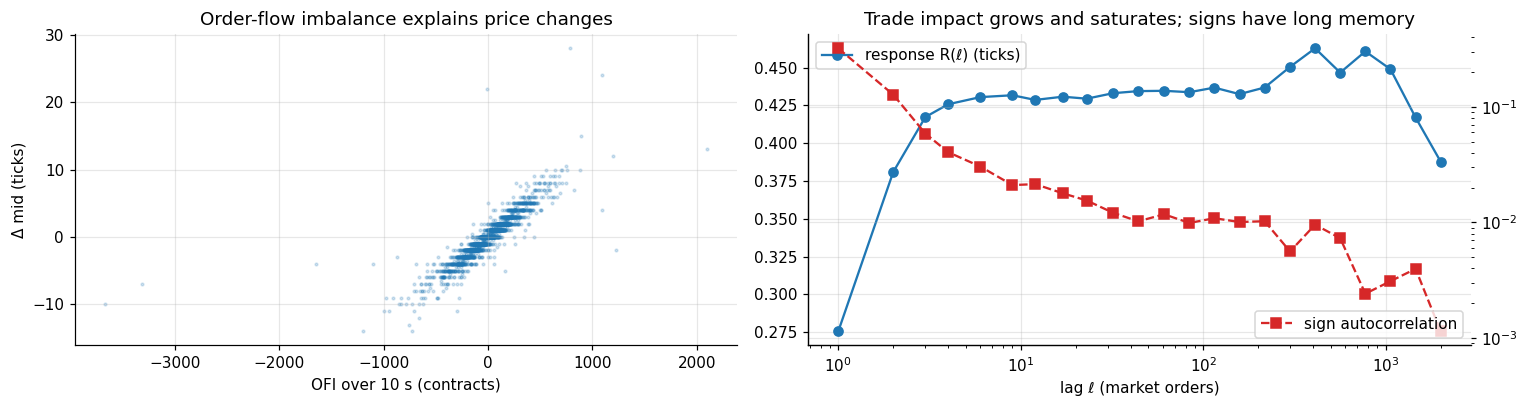

In [7]:
b = es_rth
bid, ask, qb, qa = b.bid.values, b.ask.values, b.bsz1.values.astype(float), b.asz1.values.astype(float)
e = np.zeros(len(b))
e[1:] = ((bid[1:] >= bid[:-1]) * qb[1:] - (bid[1:] <= bid[:-1]) * qb[:-1]
         - (ask[1:] <= ask[:-1]) * qa[1:] + (ask[1:] >= ask[:-1]) * qa[:-1])
ofi = pd.DataFrame({"e": e, "mid": b.mid.values, "depth": (qb + qa) / 2}, index=b.ts)
rows = []
for h in ["1s", "10s", "60s"]:
    g = ofi.resample(h).agg({"e": "sum", "mid": "last", "depth": "mean"}).dropna()
    g["dmid"] = g.mid.diff()
    g = g.dropna()
    r = sm.OLS(g.dmid, sm.add_constant(g.e)).fit()
    rows.append({"interval": h, "β (ticks per contract)": r.params.e, "t-stat": r.tvalues.e, "R²": r.rsquared, "1/mean depth": 1 / g.depth.mean()})
    if h == "10s":
        g10 = g
display(pd.DataFrame(rows).set_index("interval"))
fig, axs = plt.subplots(1, 2, figsize=(14, 3.8))
axs[0].scatter(g10.e, g10.dmid, s=3, alpha=.2); axs[0].set_xlabel("OFI over 10 s (contracts)"); axs[0].set_ylabel("Δ mid (ticks)")
axs[0].set_title("Order-flow imbalance explains price changes")
# response function R(l) = E[ε_n (m_{n+l} - m_n)] in trade time
mo_r = pd.merge_asof(mo.sort_values("ts")[["ts", "side", "size"]], es[["ts", "bid", "ask"]], on="ts", direction="backward", allow_exact_matches=False)
mo_r["m"] = (mo_r.bid + mo_r.ask) / 2
eps = np.where(mo_r.side == "B", 1.0, -1.0); mm = mo_r.m.values
L = np.unique(np.geomspace(1, 2000, 25).astype(int))
Rl = [np.nanmean(eps[:-l] * (mm[l:] - mm[:-l])) for l in L]
sign_ac = [np.corrcoef(eps[:-l], eps[l:])[0, 1] for l in L]
axs[1].semilogx(L, Rl, "o-", label="response R(ℓ) (ticks)")
ax2 = axs[1].twinx(); ax2.loglog(L, np.maximum(sign_ac, 1e-4), "s--", color="tab:red", label="sign autocorrelation")
axs[1].set_xlabel("lag ℓ (market orders)"); axs[1].set_title("Trade impact grows and saturates; signs have long memory")
axs[1].legend(loc="upper left"); ax2.legend(loc="lower right")
plt.tight_layout(); plt.show()

* OFI explains **64–75 %** of the variance of mid-price changes at 1–60 s horizons, far more than trade volume alone could. The slope
  (≈ 0.01 ticks per contract) is of the same order as 1/depth (≈ 0.04), consistent with Cont–Kukanov–Stoikov's β ∝ 1/depth: **price impact is a
  queue-depletion phenomenon**. A contract of net order flow moves the price by roughly the fraction of the best queue it consumes.
* The response function rises and then flattens. The autocorrelation of trade signs decays slowly, like a power law. That's the fingerprint
  of **metaorder splitting**: if impact were permanent and signs persistent, prices would be predictable, so liquidity providers must make
  the impact of each trade partly transient (Bouchaud's propagator picture).

### 6.2 Metaorders in the simulator: the square-root law?
We inject a buy metaorder: extra buy market orders at rate $r$ (units/s) until $Q$ units are executed, and record the mid-price relative to its
start, averaged over many simulations. Empirically, across markets, the peak impact of a metaorder follows the **square-root law**
$I(Q)\approx Y\sigma\sqrt{Q/V}$ (Tóth et al. 2011).

metaorder experiments: 9s


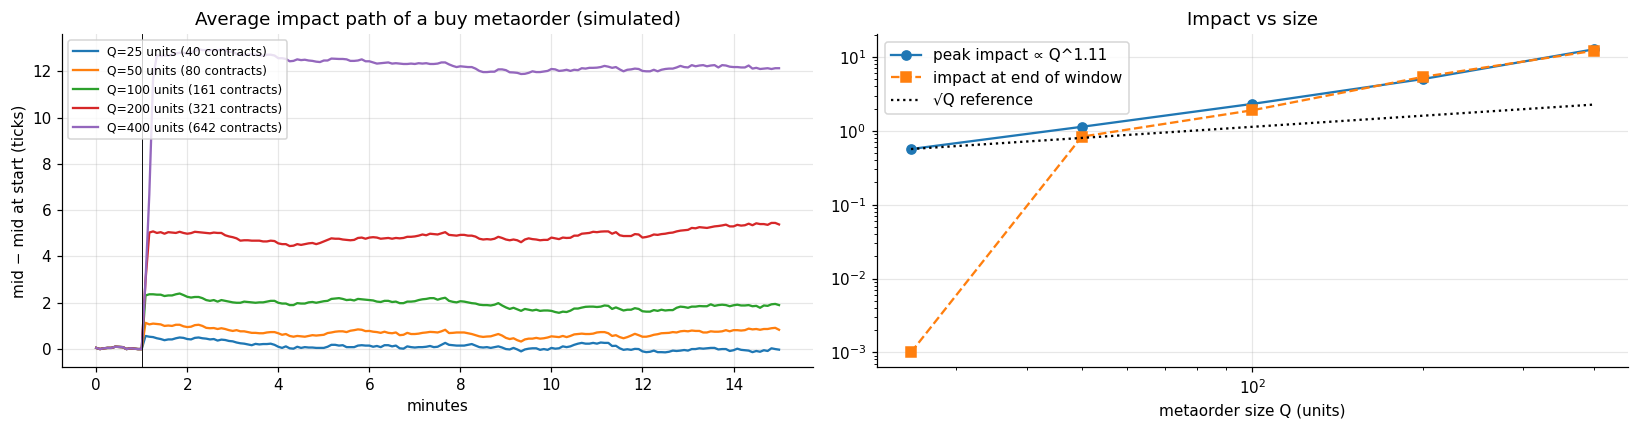

In [8]:
def metaorder_impact(Q, rate, n_rep=60, horizon=900.0):
    paths = []
    tg = np.linspace(0, horizon, 181)
    n_ev = int(horizon * (2 * lam.sum() + 2 * (theta * Qbar).sum() + 2 * mu + rate) * 1.2)
    for rep in range(n_rep):
        st_, sb_, sa_, _, _ = simulate_cst(lam, theta, mu, Qbar, n_ev, 1000 + rep, rate, float(Q), 60.0, horizon, -1.0, 0)
        m = (sb_ + sa_) / 2
        idx = np.searchsorted(st_, tg + 0.0, side="right") - 1
        mm_ = m[np.clip(idx, 0, len(m) - 1)]
        paths.append(mm_ - mm_[np.searchsorted(tg, 60.0)])
    return tg, np.mean(paths, 0), np.std(paths, 0) / np.sqrt(n_rep)


t0 = time.time()
rate = 2.0 * mu                                     # the metaorder doubles buy market-order intensity
res_imp = {}
for Q in [25, 50, 100, 200, 400]:
    res_imp[Q] = metaorder_impact(Q, rate)
print(f"metaorder experiments: {time.time()-t0:.0f}s")

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
for Q, (tg, m, se) in res_imp.items():
    axs[0].plot(tg / 60, m, label=f"Q={Q} units ({Q*S_L:.0f} contracts)")
axs[0].axvline(1, color="k", lw=.6); axs[0].set_xlabel("minutes"); axs[0].set_ylabel("mid − mid at start (ticks)")
axs[0].set_title("Average impact path of a buy metaorder (simulated)"); axs[0].legend(fontsize=8)
peak = pd.Series({Q: (lambda tg, m, se: m[np.searchsorted(tg, 60 + Q / rate)])(*v) for Q, v in res_imp.items()})
final = pd.Series({Q: v[1][-1] for Q, v in res_imp.items()})
slope = np.polyfit(np.log(peak.index), np.log(peak.clip(lower=1e-3).values), 1)[0]
axs[1].loglog(peak.index, peak.values, "o-", label=f"peak impact ∝ Q^{slope:.2f}")
axs[1].loglog(final.index, final.clip(lower=1e-3).values, "s--", label="impact at end of window")
axs[1].loglog(peak.index, peak.values[0] * np.sqrt(peak.index / peak.index[0]), "k:", label="√Q reference")
axs[1].set_xlabel("metaorder size Q (units)"); axs[1].legend(); axs[1].set_title("Impact vs size")
plt.tight_layout(); plt.show()

In the memoryless queueing model the impact of a metaorder is roughly **linear** in its size (exponent ≈ 1.1, far from ½), and it is **permanent**: nothing in the model
"knows" the buying was temporary, so queues don't strategically refill and the price doesn't revert. The empirical square-root law and the partial
reversion after completion both need ingredients the CST model lacks. Liquidity providers must *react* to order flow (latent liquidity, Donier et
al. 2015) and order flow must have long memory. This is the most important limitation of zero-intelligence models, and a good reason to
calibrate agent-based or queue-reactive models when impact is the object of study.

## 7. Resiliency
**Resiliency** is how fast the book recovers after a liquidity shock.
* *Real data:* find market orders that exhausted the best ask (buy side) or best bid, and track the depth at the new best and the spread over the
  following seconds.
* *Simulator:* wipe out the first two ask levels at a known time and track the same quantities.

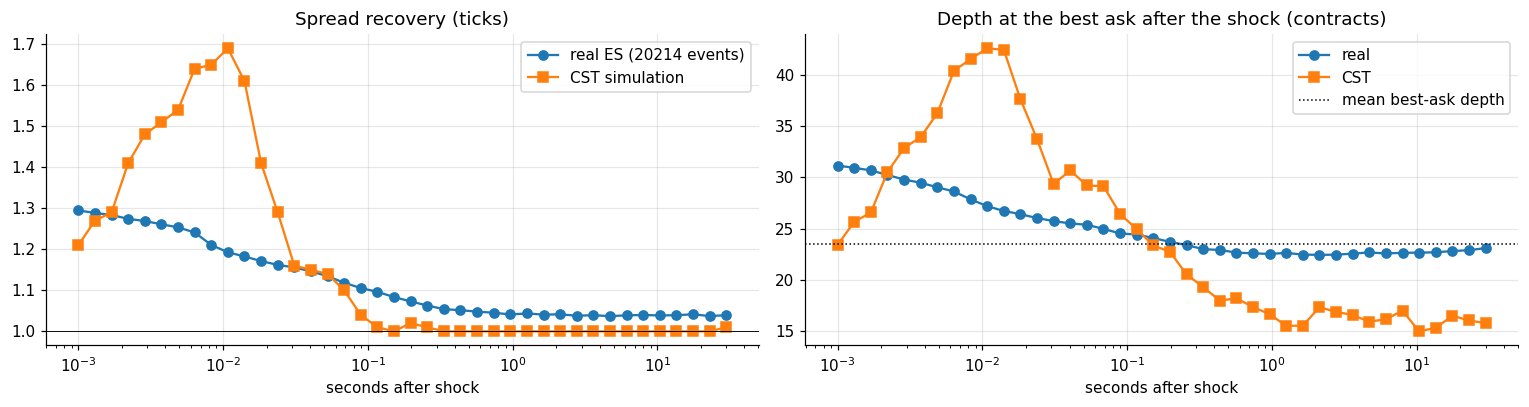

real ES: spread gap halves within ≈ 40.5 ms after a best-level depletion


In [9]:
b = es_rth[["ts", "bid", "ask", "bsz1", "asz1"]].copy()
b["ask_up"] = b.ask.diff() > 0
b["spread"] = b.ask - b.bid
shock_idx = np.where(b.ask_up.values & (b.spread.values >= 2))[0]          # ask queue emptied, spread opened
grid_s = np.r_[0, np.geomspace(0.001, 30, 40)]
paths_sp, paths_dp = [], []
ts_ns = b.ts.values.astype("int64")
for i in shock_idx[::3]:
    tt = ts_ns[i] + (grid_s * 1e9).astype("int64")
    j = np.searchsorted(ts_ns, tt, side="right") - 1
    paths_sp.append(b.spread.values[j]); paths_dp.append(b.asz1.values[j])
real_sp, real_dp = np.mean(paths_sp, 0), np.mean(paths_dp, 0)

sim_sp, sim_dp = [], []
for rep in range(100):
    st_, sb_, sa_, _, saq_ = simulate_cst(lam, theta, mu, Qbar, 60_000, 5000 + rep, 0.0, 0.0, 0.0, 0.0, 30.0, 2)
    j = np.searchsorted(st_, 30.0 + grid_s, side="right") - 1
    j = np.clip(j, 0, len(st_) - 1)
    sim_sp.append((sa_ - sb_)[j]); sim_dp.append(saq_[j] * S_L)
fig, axs = plt.subplots(1, 2, figsize=(14, 3.8))
axs[0].semilogx(grid_s[1:], real_sp[1:], "o-", label=f"real ES ({len(paths_sp)} events)"); axs[0].semilogx(grid_s[1:], np.mean(sim_sp, 0)[1:], "s-", label="CST simulation")
axs[0].axhline(1, color="k", lw=.6); axs[0].set_xlabel("seconds after shock"); axs[0].set_title("Spread recovery (ticks)"); axs[0].legend()
axs[1].semilogx(grid_s[1:], real_dp[1:], "o-", label="real"); axs[1].semilogx(grid_s[1:], np.mean(sim_dp, 0)[1:], "s-", label="CST")
axs[1].axhline(depth_prof.ask.iloc[0], color="k", ls=":", lw=1, label="mean best-ask depth")
axs[1].set_xlabel("seconds after shock"); axs[1].set_title("Depth at the best ask after the shock (contracts)"); axs[1].legend()
plt.tight_layout(); plt.show()
half_real = grid_s[np.argmax(real_sp <= 1 + (real_sp[1] - 1) / 2)] if real_sp[1] > 1 else np.nan
print(f"real ES: spread gap halves within ≈ {half_real*1000:.1f} ms after a best-level depletion")

* **Real ES:** after a best ask is exhausted and the spread opens, the average spread gap halves in ≈ 40 ms and has closed within a few hundred
  milliseconds. Depth at the new best ask starts *above* average (it was the deeper level 2) and relaxes to normal within ~0.3 s.
* **CST simulation:** the spread also closes within tens of milliseconds, because limit orders inside the spread arrive at λ(1) ≈ 49/s, one every
  ~20 ms. So *spread* resiliency is reproduced by the arrival rate alone. What the simulation gets wrong is **depth**: it relaxes toward its own lower
  equilibrium (≈ 16 contracts instead of ≈ 23). And, as §5–6 showed, the *price* doesn't revert after a shock, which is the dimension of resiliency
  that matters most for execution costs.

## 8. Latency arbitrage: ES vs MES
ES and MES are the **same** exposure (the S&P 500 at the same price), in different sizes (\$50 vs \$5 per point), trading in separate order books.
When news hits, ES (the more liquid contract) usually moves first. For a brief moment the MES quotes are **stale**, and a fast trader can buy MES at an
ask below the new ES bid (or sell at a bid above the ES ask). That's the "sniping" race of Budish, Cramton & Shim (2015): profits go to whoever is
fastest, and slow liquidity providers pay for it through adverse selection.

We merge the two reconstructed books on Databento's receive timestamp (one capture point, so relative timing is meaningful up to feed-path
differences), and find every **cross-book arbitrage window**: MES ask < ES bid, or MES bid > ES ask. Its duration is how long the opportunity lasts.

711 cross-book arbitrage windows in RTH; 87% opened by an ES move


,count,mean,std,min,10%,25%,50%,75%,90%,99%,max
window duration (µs),711.0000,"1,138.4116","2,453.8012",0.0000,52.5280,134.7420,316.3830,920.0730,"2,987.7080","11,951.5532","29,576.1880"


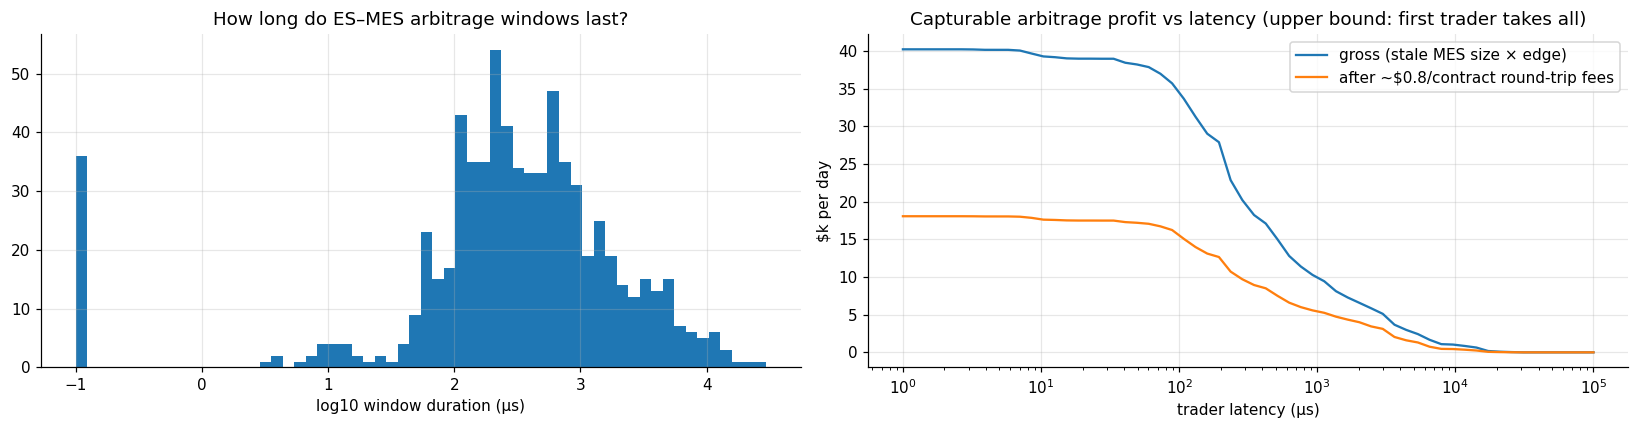

In [10]:
mes = books["MESM5"]
m = pd.concat([es[["ts", "bid", "ask", "bsz1", "asz1"]].assign(src="ES"), mes[["ts", "bid", "ask", "bsz1", "asz1"]].assign(src="MES")])
m = m[(m.ts >= RTH[0]) & (m.ts < RTH[1])].sort_values("ts", kind="stable")
for c in ["bid", "ask", "bsz1", "asz1"]:
    m[f"es_{c}"] = m[c].where(m.src == "ES").ffill()
    m[f"mes_{c}"] = m[c].where(m.src == "MES").ffill()
m = m.dropna(subset=["es_bid", "mes_bid"])
buy_mes = m.mes_ask < m.es_bid        # buy stale MES ask, sell ES bid
sell_mes = m.mes_bid > m.es_ask
arb = (buy_mes | sell_mes).values
edge = np.where(buy_mes, m.es_bid - m.mes_ask, np.where(sell_mes, m.mes_bid - m.es_ask, 0))
qty = np.where(buy_mes, m.mes_asz1, np.where(sell_mes, m.mes_bsz1, 0))
ts = m.ts.values.astype("int64")
# episodes: consecutive states with arb=True
start = np.where(arb & ~np.r_[False, arb[:-1]])[0]
end = np.where(arb & ~np.r_[arb[1:], False])[0]
dur_us = (ts[np.minimum(end + 1, len(ts) - 1)] - ts[start]) / 1e3
ep = pd.DataFrame({"start": m.ts.values[start], "duration_us": dur_us, "edge_ticks": edge[start], "mes_qty": qty[start],
                   "leader": np.where(m.src.values[start] == "ES", "ES moved (MES stale)", "MES moved (ES stale)")})
ep["profit_$"] = ep.edge_ticks * 1.25 * ep.mes_qty                  # $1.25 per tick per MES contract
print(f"{len(ep):,} cross-book arbitrage windows in RTH; {(ep.leader.str.startswith('ES')).mean():.0%} opened by an ES move")
display(ep.duration_us.describe(percentiles=[.1, .25, .5, .75, .9, .99]).to_frame("window duration (µs)").T)

lat = np.geomspace(1, 1e5, 60)              # trader latency in microseconds
fees = 0.35 * 2 + 0.035 * 2                   # rough all-in exchange+clearing $/MES round trip (+ ES hedge share) — assumption
cap = [ep.loc[ep.duration_us > L_, "profit_$"].sum() for L_ in lat]
cap_net = [(ep.loc[ep.duration_us > L_, "profit_$"] - fees * ep.loc[ep.duration_us > L_, "mes_qty"]).clip(lower=0).sum() for L_ in lat]
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].hist(np.log10(ep.duration_us.clip(lower=0.1)), bins=60)
axs[0].set_xlabel("log10 window duration (µs)"); axs[0].set_title("How long do ES–MES arbitrage windows last?")
axs[1].semilogx(lat, np.array(cap) / 1e3, label="gross (stale MES size × edge)")
axs[1].semilogx(lat, np.array(cap_net) / 1e3, label="after ~$0.8/contract round-trip fees")
axs[1].set_xlabel("trader latency (µs)"); axs[1].set_ylabel("$k per day"); axs[1].legend()
axs[1].set_title("Capturable arbitrage profit vs latency (upper bound: first trader takes all)")
plt.tight_layout(); plt.show()

**Reading the results.**
* There were ~700 cross-book windows during the session, and **~87 % were opened by an ES move**: ES leads price discovery and MES follows.
* Windows are **short**: the median lasts ≈ 0.3 ms, a quarter last under ~0.13 ms, and only ~10 % survive 3 ms. (Receive timestamps also include
  the difference in the two feeds' network paths, so the very shortest windows are partly measurement.)
* The upper-bound profit is ≈ \$40 k for the day for a trader reacting within ~10 µs. It halves by ≈ 300 µs and is essentially gone beyond ~10 ms. After a
  rough fee assumption the pool is roughly halved again. This is the race Budish–Cramton–Shim describe: the prize per event is small, and it goes to
  the fastest firm. The cost of losing the race falls on MES liquidity providers (their stale quotes get picked off), which they recover through
  wider spreads or thinner depth.
* **Caveats.** The profit is an *upper bound*: it assumes the first sniper gets the whole stale quantity and fills the ES hedge at the observed bid/ask
  (ES is 10× MES, so a real hedge needs 10 MES per ES). Queue priority and competing snipers are ignored, and the fee is a rough assumption. Receive
  timestamps include each feed's own path latency.

## 9. Strengths, weaknesses, extensions
**Strengths**
* Built from the rawest possible data: every order and cancel, nanosecond timestamps, and a verified book (never crossed, trades at the quotes).
* The CST model is calibrated from simple counts, simulates exactly, and gives a transparent null model against which real-market features stand out.
* Real-data measurements (OFI, response functions, resiliency, cross-book latency) need no model at all.

**Weaknesses**
* **One day, one product**: rates and shapes vary with volatility regime, time of day and the roll cycle.
* **Zero-intelligence dynamics**: memoryless Poisson flow gives the wrong impact law (≈ linear, permanent), too-slow resiliency, and no strategic
  behaviour. It is a benchmark, not a realistic market.
* **Hidden liquidity**: CME has implied (spread-leg) liquidity and iceberg orders; MBO shows only the displayed part.
* The latency analysis is an upper bound, with no queue position, no competition and no hedging frictions.

**Extensions**
* Queue-reactive model (Huang–Lehalle–Rosenbaum 2015) with state-dependent rates; Hawkes processes for clustered, self-exciting order flow.
* Agent-based markets (market makers with inventory control à la Avellaneda–Stoikov, momentum/noise traders, informed traders) in ABIDES, calibrated
  to the stylised facts above.
* Estimate the propagator kernel and the square-root law from real ES metaorders (sequences of same-sign aggressive orders).
* Extend the latency study to NQ/MNQ and to ES vs SPY (cross-venue, cross-asset), where the lead–lag is milliseconds.

**References.** Cont, Stoikov & Talreja, "A stochastic model for order book dynamics", *Operations Research* (2010); Cont, Kukanov & Stoikov, "The price
impact of order book events", *J. Financial Econometrics* (2014); Huang, Lehalle & Rosenbaum, "Simulating and analyzing order book data: the queue-reactive
model", *JASA* (2015); Bouchaud, Bonart, Donier & Gould, *Trades, Quotes and Prices* (2018); Budish, Cramton & Shim, "The high-frequency trading arms race",
*QJE* (2015); Tóth et al., "Anomalous price impact and the critical nature of liquidity" (2011).